# Predicting Employee Performance Using Machine Learning and Explainable AI

## Notebook 1 – Data Understanding

**Student:** Funwayo Nkhata

**Programme:** MSc Data Science

**Supervisor:** Dr Kat Fair



## Objective

The purpose of this notebook is to perform an initial exploration of the Employee Performance dataset. This stage focuses on understanding the structure of the data, assessing its quality, identifying potential issues such as missing values and duplicates, and exploring the characteristics of the variables before any data cleaning or machine learning activities are undertaken.

The findings from this notebook will provide the foundation for data preprocessing, feature engineering, predictive modelling and Explainable Artificial Intelligence (XAI) in the later stages of the project.

# Development Environment

The analysis was conducted using Python within Jupyter Notebook, running through Visual Studio Code and the Anaconda distribution. This environment was selected because it enables code, visualisations, outputs and documentation to be combined within a single reproducible workflow.

The following libraries are required throughout the project:

- Pandas for data manipulation and analysis.
- NumPy for numerical computation.
- Matplotlib for data visualisation.
- Scikit-learn for machine learning.

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print("Environment working successfully")

Environment working successfully


In [2]:
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 2.3.3
NumPy: 2.3.5
Scikit-learn: 1.7.2


## Dataset Source

The dataset used in this project is a **synthetic dataset** obtained from **Kaggle**. Although it has been designed to reflect realistic organisational and employee characteristics, it does not contain real employee records. Consequently, the findings, relationships and predictive performance presented throughout this project should be interpreted within the context of synthetic data rather than as evidence of real-world organisational behaviour.

## Load the Dataset

The dataset is stored within the project Data folder. The dataset is loaded into a Pandas DataFrame, allowing it to be inspected and analysed throughout the remainder of this notebook.

In [3]:
import pandas as pd

df = pd.read_csv("../Data/Employee Data.csv")

df.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,03:05.6,2,High School,5,6750,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,03:05.6,0,High School,5,7500,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,03:05.6,8,High School,3,5850,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,03:05.6,7,Bachelor,2,4800,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,03:05.6,3,Bachelor,2,4800,38,11,29,13,100,15,9,1,1.25,False


## Previewing the Dataset

The first five rows of the dataset were examined to verify that the data had been imported correctly and to gain an initial understanding of the available variables.

## Dataset Dimensions

The first step is to understand the overall size of the dataset by identifying the number of observations (rows) and variables (columns). This provides an indication of the amount of information available for modelling.

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 100000
Columns: 20


The dataset contains 100,000 observations and 20 variables describing employee demographics, education, experience, job characteristics and performance. These variables will be explored further throughout the project.

## Data Types and Structure

The structure of the dataset was examined to identify variable names, data types and completeness.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  int64  
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

The dataset contains a mixture of numerical and categorical variables representing employee demographic, behavioural and organisational characteristics. All variables contain complete records.

## Summary Statistics

Descriptive statistics were generated to understand the distribution and characteristics of numerical variables within the dataset.

In [6]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


## Interpretation of Summary Statistics

The descriptive statistics provide an overview of the numerical variables contained within the Employee Performance dataset and offer valuable insights into the characteristics of the workforce.

The dataset contains **100,000 employee records** for each numerical variable, indicating that there are no missing values within the numerical features analysed. This confirms that the dataset is complete and suitable for subsequent machine learning analysis without requiring imputation.

The average employee age is **41 years**, with ages ranging from **22 to 60 years**, suggesting that the dataset represents employees at various stages of their careers. The relatively large standard deviation (11.24 years) indicates a diverse workforce with a broad age distribution.

Employees have worked at the company for an average of approximately **4.5 years**, with service lengths ranging from **0 to 10 years**. This suggests that the dataset includes both newly recruited employees and more experienced staff, which may influence performance outcomes.

The average **Performance Score** is **3.0** on a five-point scale, with scores ranging from **1 to 5**. The mean and median are almost identical, indicating that employee performance is relatively evenly distributed across the dataset without obvious skewness.

Monthly salaries average approximately **£6,403**, with salaries ranging between **£3,850 and £9,000**. The standard deviation of approximately **£1,373** suggests a reasonable level of variation in employee remuneration, which may reflect differences in job roles, seniority and experience.

Employees work an average of approximately **45 hours per week**, with working hours varying between **30 and 60 hours**. This variation may provide useful information when investigating whether workload influences employee performance.

The dataset also shows considerable variation in employee workload and engagement measures. Employees handle an average of **24 projects**, complete approximately **15 hours of overtime**, and take an average of **7 sick days** per year. These variables may prove to be important predictors of employee performance.

Remote working frequency ranges from **0% to 100%**, with an average of approximately **50%**, indicating that the dataset includes employees working across a wide spectrum of hybrid and remote working arrangements.

Training hours average approximately **50 hours**, while employees have received an average of **one promotion** during their employment. These variables may provide valuable insight into employee development and career progression.

Finally, the average **Employee Satisfaction Score** is **3.0** on a five-point scale, with responses covering the full range from **1 to 5**. This variation suggests differing levels of employee satisfaction and may represent an important explanatory variable when predicting employee performance.

Overall, the descriptive statistics indicate that the dataset contains substantial variability across demographic, employment and performance-related variables. The absence of missing values and the broad distribution of observations provide a strong foundation for exploratory data analysis, feature engineering and predictive modelling in the subsequent stages of the project.

In [7]:
df.describe(include="object")

,Department,Gender,Job_Title,Hire_Date,Education_Level
count,100000,100000,100000,100000,100000
unique,9,3,7,1,4
top,Marketing,Male,Specialist,03:05.6,Bachelor
freq,11216,48031,14507,100000,50041


In [8]:
df["Gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

## Interpretation of Categorical Variables

The summary statistics for the categorical variables provide an overview of the composition of the workforce and confirm that all categorical features contain **100,000 valid observations**, indicating that no missing values are present within these variables.

The **Department** variable contains **nine unique departments**, with **Marketing** representing the largest group, accounting for **11,216 employees**. This suggests that the dataset includes a broad representation of organisational functions, which may influence employee performance differently across departments.

The **Gender** variable contains **three categories**, with **Male** employees representing the largest group (**48,031 employees**). The presence of multiple gender categories indicates that the dataset captures workforce diversity and allows potential relationships between gender and employee performance to be explored.

The **Job_Title** variable consists of **seven unique job roles**, with **Specialist** being the most common position (**14,507 employees**). This variation suggests that employees occupy a range of organisational roles with differing levels of responsibility, workload and experience, all of which may contribute to variations in performance.

The **Education_Level** variable contains **four qualification levels**, with **Bachelor's degree** being the most frequently occurring qualification (**50,041 employees**). Education level may represent an important explanatory variable when investigating employee capability and performance outcomes.

The **Hire_Date** variable contains only **one unique value**, indicating that every employee shares the same recorded hire date. This is unusual for an employee dataset and suggests that the variable may have been incorrectly imported or may not represent the original hiring date. Consequently, this variable is unlikely to provide useful predictive information in its current form and should be investigated further during the data cleaning stage.

Overall, the categorical variables demonstrate good data completeness and provide a diverse range of employee characteristics that are likely to contribute valuable information during exploratory data analysis, feature engineering and predictive model development. The `Hire_Date` variable contains only one unique value (`03:05.6`) across all 100,000 records. This confirms that the variable does not represent valid employee hire dates and contains no useful variation for predictive modelling. The issue is investigated further in the following section.

In [9]:
df["Hire_Date"].head(10)

0    03:05.6
1    03:05.6
2    03:05.6
3    03:05.6
4    03:05.6
5    03:05.6
6    03:05.6
7    03:05.6
8    03:05.6
9    03:05.6
Name: Hire_Date, dtype: object

## Investigation of the Hire_Date Variable

During the data understanding stage, the `Hire_Date` variable was investigated to determine its suitability for predictive modelling. Inspection revealed that all 100,000 records contained the identical value (`03:05.6`), rather than valid calendar dates.

As the variable exhibits no variation across observations, it provides no meaningful information for distinguishing between employees and therefore cannot contribute to predictive model performance. The issue is likely to originate from the source dataset, as the data was downloaded directly from Kaggle in CSV format.

From a machine learning perspective, variables with a single constant value have no predictive power because they do not contain any information that can explain differences in the target variable. Consequently, the `Hire_Date` feature will be removed during the data preprocessing stage. This decision is documented to ensure transparency and reproducibility within the data preparation process.

In [10]:
numeric_columns = df.select_dtypes(include="number").columns
numeric_columns

Index(['Employee_ID', 'Age', 'Years_At_Company', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score'],
      dtype='object')

In [11]:
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns

Index(['Department', 'Gender', 'Job_Title', 'Hire_Date', 'Education_Level'], dtype='object')

## Missing Values Assessment

A missing value assessment was conducted to determine whether any variables contained incomplete observations.

In [12]:
df.isnull().sum()

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64

No missing values were identified across any variables within the dataset. Therefore, no imputation procedures were required.

## Duplicate Records Assessment

A duplicate record assessment was conducted to identify any repeated observations that may affect the validity of subsequent analyses.

In [13]:
df.duplicated().sum()

np.int64(0)

No duplicate records were identified within the dataset. Therefore, no duplicate removal procedures were required.

## Dataset Description

The dataset contains 100,000 employee records and 20 variables describing demographic, behavioural and organisational characteristics.

The variables include employee age, department, education level, work patterns, training activity, satisfaction scores and performance outcomes.

The dataset was selected because its large sample size provides sufficient observations for robust statistical analysis, machine learning model development and performance evaluation. The breadth of variables available also supports investigation of the factors influencing employee performance.

## Target Variable

The target variable selected for prediction is Performance_Score. This variable represents employee performance on a scale from 1 to 5 and will be used as the dependent variable in the predictive modelling phase of the project.

All remaining variables will be treated as potential predictor variables.

## Summary

The initial data quality assessment confirmed that the dataset is complete, with no missing values or duplicate records. The dataset contains a large number of observations and a diverse range of workforce-related variables, making it suitable for machine learning analysis.

The next stage of the project will involve Exploratory Data Analysis (EDA) to investigate distributions, relationships and potential predictors of employee performance.

# Exploratory Data Analysis (EDA)

In [14]:
df['Performance_Score'].value_counts().sort_index()

Performance_Score
1    20120
2    20013
3    19999
4    19940
5    19928
Name: count, dtype: int64

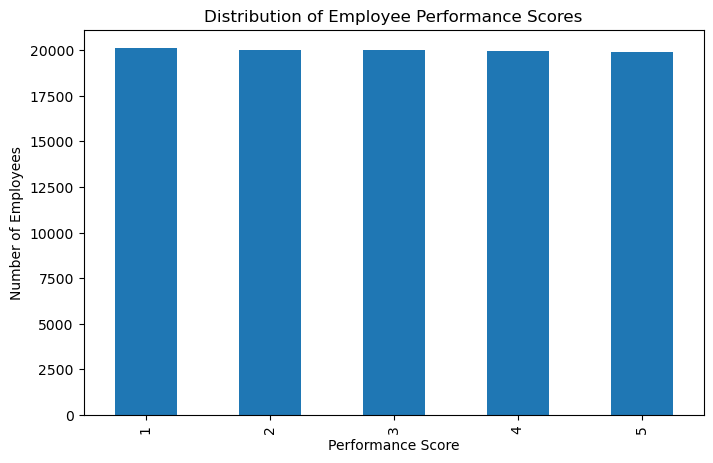

In [15]:
plt.figure(figsize=(8,5))
df["Performance_Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Employee Performance Scores")
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")
plt.show()

## Interpretation of Performance Score Distribution

The distribution of `Performance_Score` is broadly balanced across the five performance categories. Each category contains approximately 20,000 observations, with scores ranging from 1 to 5. This indicates that the target variable is not materially imbalanced.

This is beneficial for supervised machine learning because the model will have sufficient examples from each performance category during training. A balanced target variable reduces the risk of the model becoming biased towards one dominant class and supports fairer evaluation of predictive performance across all categories.

The balanced distribution also confirms that `Performance_Score` is suitable for use as the target variable in the modelling phase of the project.

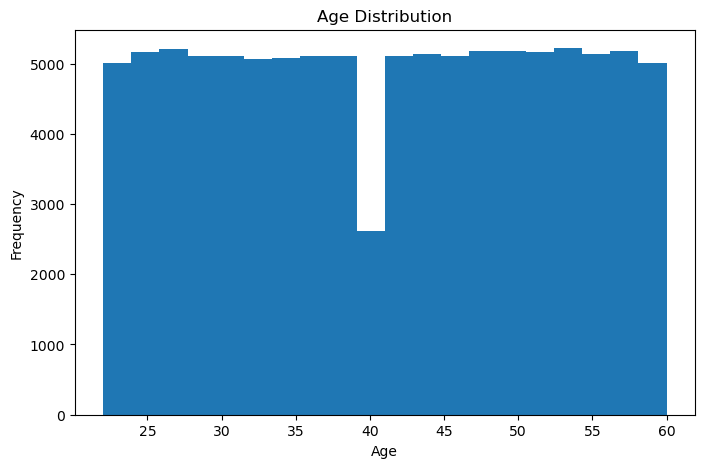

In [16]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Interpretation of Age Distribution

The age distribution shows that employees range from 22 to 60 years old, with observations spread across the full working-age range. This suggests that the dataset includes employees at different career stages, which may be useful when investigating factors associated with employee performance.

The distribution appears broadly even, although there is a slight dip around the late-thirties to early-forties range. This may reflect the synthetic nature of the dataset and should be considered when interpreting the results.

In [17]:
df['Department'].value_counts()

Department
Marketing           11216
Finance             11200
Operations          11181
IT                  11131
Sales               11122
Legal               11118
Customer Support    11116
HR                  10960
Engineering         10956
Name: count, dtype: int64

In [18]:
df['Gender'].value_counts()

Gender
Male      48031
Female    48001
Other      3968
Name: count, dtype: int64

In [19]:
df['Education_Level'].value_counts()

Education_Level
Bachelor       50041
High School    30004
Master         14904
PhD             5051
Name: count, dtype: int64

## Interpretation of Department, Gender and Education Distributions

The department distribution is relatively balanced, with each department containing approximately 11,000 employees. This reduces the likelihood that one department will dominate the modelling process.

The gender variable contains three categories: `Male`, `Female` and `Other`. Male and Female employees represent the largest groups, while the Other category contains a smaller but valid group. This is not a data quality issue and should be retained during preprocessing.

The education distribution shows that Bachelor-level education is the most common qualification, followed by High School, Master and PhD. These categorical variables are potentially useful predictors and will require encoding before machine learning models can use them.

In [20]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
Employee_ID,1.000000,0.004010,-0.007175,-0.002077,-0.002050,-0.000968,-0.000706,-0.005254,0.000745,-0.000347,0.002027,-0.002966,-0.000778,-0.001595
Age,0.004010,1.000000,0.000078,0.001598,0.002757,-0.003050,-0.001726,0.001875,0.006981,-0.004672,-0.003411,0.002045,-0.002888,-0.000124
Years_At_Company,-0.007175,0.000078,1.000000,0.001598,-0.000645,0.002578,0.002963,0.001965,-0.004371,-0.002443,0.003250,0.002696,-0.002737,-0.003180
Performance_Score,-0.002077,0.001598,0.001598,1.000000,0.510035,-0.005627,0.000640,-0.001312,0.002994,0.001733,-0.005174,0.002358,-0.003501,0.001696
Monthly_Salary,-0.002050,0.002757,-0.000645,0.510035,1.000000,-0.002347,-0.001925,-0.003029,0.003610,-0.000464,0.002972,-0.001088,-0.001940,0.001083
Work_Hours_Per_Week,-0.000968,-0.003050,0.002578,-0.005627,-0.002347,1.000000,-0.004183,0.005787,-0.000838,-0.004618,0.000790,0.001287,0.000238,0.000530
Projects_Handled,-0.000706,-0.001726,0.002963,0.000640,-0.001925,-0.004183,1.000000,0.004107,-0.004995,0.000484,0.003813,0.002211,-0.002344,0.006126
Overtime_Hours,-0.005254,0.001875,0.001965,-0.001312,-0.003029,0.005787,0.004107,1.000000,0.004255,-0.004349,0.002175,0.002939,-0.002537,0.001052
Sick_Days,0.000745,0.006981,-0.004371,0.002994,0.003610,-0.000838,-0.004995,0.004255,1.000000,0.000478,0.000149,0.000347,-0.003044,-0.000893
Remote_Work_Frequency,-0.000347,-0.004672,-0.002443,0.001733,-0.000464,-0.004618,0.000484,-0.004349,0.000478,1.000000,-0.000668,0.005227,-0.000537,-0.001408


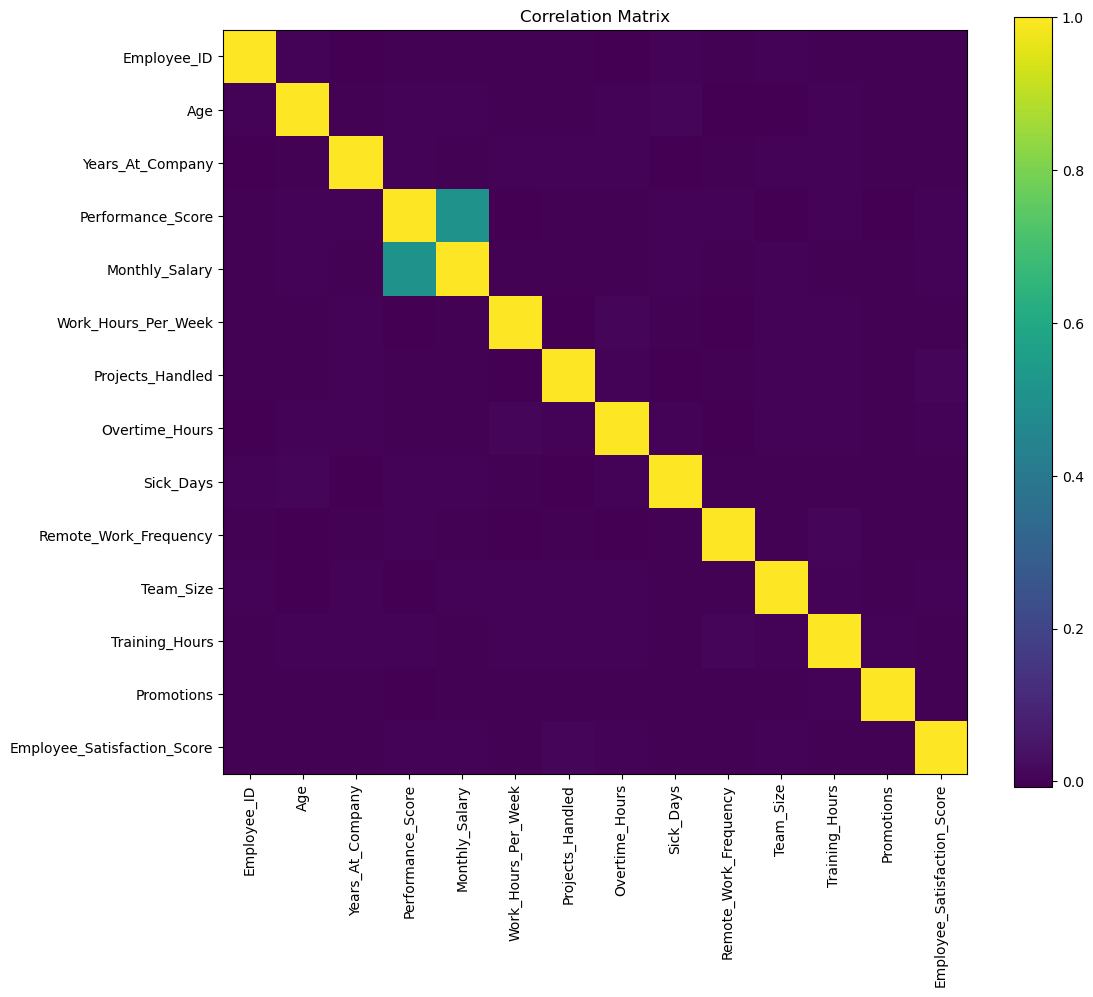

In [21]:
plt.figure(figsize=(12,10))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

## Interpretation of the Correlation Matrix

The correlation matrix was generated to examine the strength and direction of the linear relationships between the numerical variables in the dataset. Correlation analysis is an important exploratory step because it helps identify potential relationships between variables, detect multicollinearity, and provide insight into which features may contribute to predictive modelling.

Overall, the majority of variables exhibit **very weak correlations**, with correlation coefficients close to **zero**. This indicates that most employee characteristics are largely independent of one another and that there is limited evidence of multicollinearity within the dataset. From a machine learning perspective, this is beneficial because highly correlated predictor variables can introduce redundancy and negatively affect the performance and interpretability of some algorithms.

The most notable relationship is observed between **Performance_Score** and **Monthly_Salary**, which have a **moderate positive correlation (r = 0.510)**. This suggests that employees with higher performance scores generally tend to receive higher salaries. While correlation does not imply causation, this relationship is consistent with expectations in many organisations where employee performance may influence remuneration through performance-related pay, bonuses or career progression.

In contrast, variables such as **Age**, **Years_At_Company**, **Work_Hours_Per_Week**, **Projects_Handled**, **Overtime_Hours**, **Sick_Days**, **Remote_Work_Frequency**, **Team_Size**, **Training_Hours**, **Promotions**, and **Employee_Satisfaction_Score** demonstrate negligible linear relationships with one another, with correlation coefficients generally below **±0.01**. This suggests that these variables provide largely independent information and may each contribute unique predictive value during model development.

The **Employee_ID** variable also exhibits negligible correlations with all other variables. As this variable functions solely as a unique identifier rather than an explanatory feature, it does not contain predictive information and will be removed during the data preprocessing stage.

Overall, the correlation analysis indicates that the dataset exhibits low multicollinearity and contains a diverse set of relatively independent predictor variables. This is advantageous for machine learning because it reduces redundancy between features while preserving potentially useful information for predicting employee performance.

In [22]:
df.groupby("Performance_Score")["Monthly_Salary"].mean()

Performance_Score
1    5422.229125
2    5900.284815
3    6409.515476
4    6897.632899
5    7397.669109
Name: Monthly_Salary, dtype: float64

## Relationship Between Performance Score and Monthly Salary

To further investigate the strongest relationship identified in the correlation matrix, the average monthly salary was calculated for each employee performance category.

The results show a clear and consistent increase in average monthly salary as employee performance scores increase. Employees with a **Performance Score of 1** earn an average monthly salary of approximately **£5,422**, whereas employees with a **Performance Score of 5** earn an average of approximately **£7,398**. This represents an increase of almost **£2,000 per month** across the performance scale.

This finding supports the moderate positive correlation (**r = 0.510**) observed between **Monthly_Salary** and **Performance_Score**, suggesting that higher-performing employees tend to receive higher levels of remuneration. Such a relationship is plausible within many organisations, where salary progression may be influenced by performance appraisals, promotions, experience or merit-based pay structures.

However, it is important to recognise that this dataset is synthetic and was obtained from Kaggle. Consequently, the relationship may have been intentionally incorporated during dataset generation to reflect realistic organisational behaviour rather than being derived from real-world employee records.

From a machine learning perspective, **Monthly_Salary** is likely to be an important predictor of employee performance. Nevertheless, care should be taken when interpreting model results, as the strong relationship may increase the influence of salary on model predictions. This relationship will be examined further during feature importance analysis and Explainable Artificial Intelligence (XAI) using SHAP values later in the project.

#  Key Findings

The data understanding stage provided a comprehensive assessment of the Employee Performance dataset and confirmed its suitability for predictive modelling using machine learning techniques. The principal findings are summarised below:

- The dataset contains **100,000 employee records** and **20 variables**, providing a sufficiently large sample for robust statistical analysis, machine learning model development and reliable model evaluation.

- The dataset consists of a combination of **numerical**, **categorical** and **Boolean** variables describing employee demographics, employment characteristics, workload, organisational factors and performance outcomes. This diversity provides a rich set of potential predictor variables.

- No missing values were identified across any of the variables. Consequently, no imputation procedures are required, reducing the risk of introducing bias during data preprocessing.

- No duplicate records were detected, indicating that each employee represents a unique observation and confirming the integrity of the dataset.

- Descriptive statistical analysis showed substantial variation across the numerical variables, including age, salary, working hours, overtime, training hours, promotions and employee satisfaction. This variability provides meaningful information that may contribute to predictive model performance.

- The categorical variables contain a broad representation of employee characteristics, including **nine departments**, **seven job roles**, **four education levels**, and **three gender categories (Male, Female and Other)**. These variables are expected to contribute valuable information following appropriate categorical encoding.

- Investigation of the **Hire_Date** variable revealed that every observation contains the identical value (`03:05.6`). This indicates that the variable does not represent valid employee hire dates and contains no useful predictive information. As a result, this feature will be removed during the data preprocessing stage.

- Exploratory analysis of the target variable demonstrated that **Performance_Score** is evenly distributed across the five performance categories, with approximately **20,000 observations** in each class. This balanced distribution is advantageous for supervised machine learning because it reduces the likelihood of class imbalance affecting model performance and supports reliable model training.

- Correlation analysis identified generally weak relationships between most predictor variables, indicating **low multicollinearity** within the dataset. This suggests that the majority of variables provide relatively independent information, which is beneficial for predictive modelling and feature selection.

- The strongest linear relationship identified was between **Monthly_Salary** and **Performance_Score** (*r* = **0.510**). Employees with higher performance scores consistently receive higher average monthly salaries, suggesting that salary may be an influential predictor of employee performance. However, this relationship will require careful interpretation during model development because the dataset is synthetic and may contain deliberately generated relationships.

- The **Employee_ID** variable functions solely as a unique identifier and demonstrates no meaningful relationship with the remaining variables. Consequently, it will also be excluded during data preprocessing because it provides no predictive value.

Overall, the dataset demonstrates a **high level of data quality**, with complete observations, no duplicate records and a balanced target variable. Apart from the removal of the non-informative **Hire_Date** and **Employee_ID** variables, the dataset requires minimal cleaning and provides a strong foundation for exploratory data analysis, feature engineering, predictive modelling and Explainable Artificial Intelligence (XAI). The next stage of the project will focus on data preprocessing to prepare the dataset for machine learning model development.

## Preliminary Observations for Feature Selection

The exploratory data analysis identified **Monthly_Salary** as having the strongest statistical relationship with employee performance. Furthermore, average salary increased consistently across the five performance categories.

While this relationship suggests that salary is highly informative for prediction, it also raises the possibility that salary may represent a post-outcome variable influenced by organisational grade, responsibility and previous performance evaluations. Similarly, variables such as **Promotions** and **Resigned** may reflect events occurring after or as a consequence of employee performance rather than acting as genuine predictors.

These observations will be investigated further during the data preprocessing stage to minimise the risk of target leakage and improve the practical applicability of the predictive models.